In [1]:
using DifferentialEquations, LinearAlgebra, Plots
Threads.nthreads()

7

### Initialization

In [13]:
#Basis state
r = [0;1]
g = [1;0]

#initial state of the system
α = 1/2
β = sqrt(1-α^2)
ψ_a = α.*r + β.*g
ψ_1 = g

ψ_0 = [g,ψ_a,g]
ρ_0 = complex(reduce(kron,ψ_0) * reduce(kron,ψ_0)');

### Functions

In [14]:
struct parameters
    Ω1::Float64
    Ω2::Float64     
    γ_Decay::Float64     
    γ_dephase::Float64
    V1_nn::Float64 
    V2_nn::Float64
 end

In [15]:
nothing
function (p::parameters)(t)
    global Δ1_0 = Δ1_0
    global δ1 =  δ1
    global Δ2_0 = Δ2_0
    global δ2 =  δ2

    # tf = -2*(Δ1_0+p.V1_nn)/δ1
    return (Δ1_0+δ1*t, Δ2_0+δ2*t, p.Ω1, p.Ω2, p.γ_Decay, p.γ_dephase, p.V1_nn, p.V2_nn)
end


#Master Equation
nothing
function master_eqn(dρ,ρ,p,t)

    n_atoms = 2
    #2x2 Matrices
    σ_x = [0 1; 1 0]
    n = [0 0; 0 1]
    Π_g = [1 0; 0 0]
    I = [1 0; 0 1]
    σ_minus = [0 1; 0 0]
    σ_plus = [0 0; 1 0]
    σ_z = [1 0; 0 -1]

    #parameters
    Δ1_t, Δ2_t, Ω1, Ω2, γ_Decay, γ_dephase, V1_nn, V2_nn = p(t)


    #Hamiltonian elements
    nn_sys = [kron(n,n,I), kron(I,n,n)] 
    σminus_sys = [reduce(kron,[σ_minus,I,I]),reduce(kron,[I,σ_minus,I]),reduce(kron,[I,I,σ_minus])]
    σplus_sys = [reduce(kron,[σ_plus,I,I]),reduce(kron,[I,σ_plus,I]), reduce(kron,[I,I,σ_plus])]
    σz_sys = [reduce(kron,[σ_z,I,I]), reduce(kron,[I,σ_z,I]), reduce(kron,[I,I,σ_z])]
    n_sys = [reduce(kron,[n,I,I]),reduce(kron,[I,n,I]), reduce(kron,[I,I,n])]
    σx_sys = [reduce(kron,[σ_x,I,I]), reduce(kron,[I,σ_x,I]), reduce(kron,[I,I,σ_x])]

    #Hamiltonian
    H = Ω1/2 .* σx_sys[1] + Ω2/2 .* σx_sys[3] + V1_nn .* nn_sys[1] + V2_nn.* nn_sys[2] +
        Δ1_t .* n_sys[1] + Δ2_t .*n_sys[3]

    #lindbaldian terms
    l_decay = zeros(2^(n_atoms+1),2^(n_atoms+1))
    l_dephase = zeros(2^(n_atoms+1),2^(n_atoms+1))

    for i in 1:3
        l_decay += γ_Decay.*(σminus_sys[i] * ρ * σplus_sys[i] - 0.5.*((σplus_sys[i]*σminus_sys[i]*ρ)
                         + (ρ*σplus_sys[i]*σminus_sys[i])))
        l_dephase += γ_dephase.*(σz_sys[i]* ρ *σz_sys[i] - ρ)
    end

    dρ .= -1im .* (H*ρ - ρ*H) + l_decay + l_dephase
end


#Solving the master equation
nothing
function solve_master_eqn(p)
    global δ1 = δ1
    tspan = (0.0,-2*(Δ1_0+p(0)[end-1])/δ1)
    eqn = ODEProblem(master_eqn, ρ_0, tspan, p)
    sol = solve(eqn, Rodas3(autodiff=false),saveat=0.01)
    return sol
end


# Extracting populations from the solution
nothing
function rydberg_populations(sol)
    n = [0 0; 0 1]
    I = [1 0; 0 1]

    a = reduce(kron,[I,n,I])
    rydberg2 = [real(tr(a*ρ)) for ρ in sol.u]

    b = reduce(kron,[I,I,n])
    rydberg3 = [real(tr(b*ρ)) for ρ in sol.u]

    c = reduce(kron,[n,I,I])
    rydberg1 = [real(tr(c*ρ)) for ρ in sol.u]

    c = reduce(kron,[n,I,n])
    rydberg13 = [real(tr(c*ρ)) for ρ in sol.u]

    return rydberg1, rydberg2, rydberg3, rydberg13
end

rydberg_populations (generic function with 1 method)

### System Dynamics

In [16]:
Δ1_0 = 1038
δ1 = -0.179
Δ2_0 = 1038
δ2 = -0.179
p = parameters(1,1,0,0,-1000,-1000)

tspan = (0.0,-2*(Δ1_0+p(0)[end-1])/δ1)
eqn = ODEProblem(master_eqn, ρ_0, tspan, p)
solution = solve(eqn, Rodas3(autodiff=false),saveat=1);

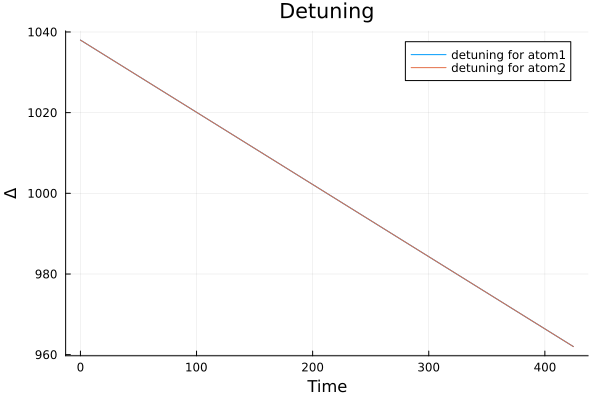

In [17]:
T = solution.t
Δ1_T = Array{Float64}(undef,length(T))
Δ2_T = Array{Float64}(undef,length(T))

for i in 1:length(T)
    t = T[i]
    Δ1_T[i] = p(t)[1]
    Δ2_T[i] = p(t)[2]
end
plot(T,Δ1_T,label="detuning for atom1",xaxis="Time",yaxis="Δ",title="Detuning")
plot!(T,Δ2_T,label="detuning for atom2",xaxis="Time",yaxis="Δ",title="Detuning")

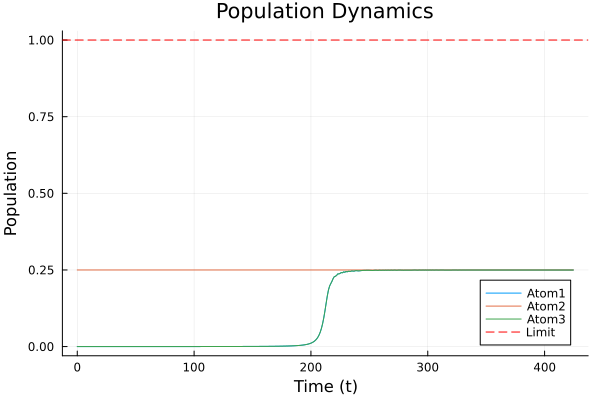

In [18]:
r1,r2,r3,r13 = rydberg_populations(solution)

# Plotting the Rydberg state population over time
plot(solution.t, r1, label="Atom1", xlabel="Time (t)", ylabel="Population", title="Population Dynamics")#,xlim=(800,1200))
plot!(solution.t, r2, label="Atom2", xlabel="Time (t)", ylabel="Population", title="Population Dynamics")#,xlim=(800,1200))
plot!(solution.t, r3, label="Atom3", xlabel="Time (t)", ylabel="Population", title="Population Dynamics")#,xlim=(800,1200))
hline!([1],color=:red,linestyle=:dash,label="Limit")

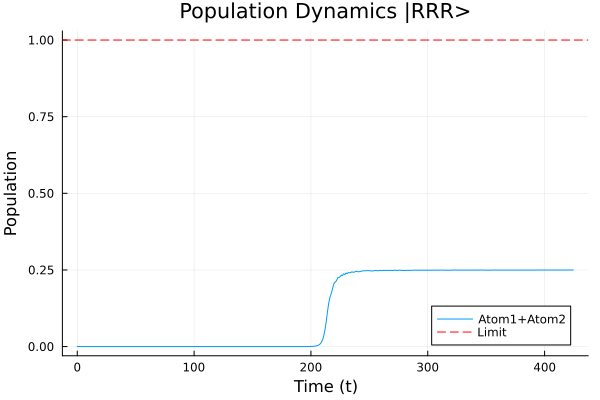

In [19]:
plot(solution.t, r13, label="Atom1+Atom2", xlabel="Time (t)", ylabel="Population", title="Population Dynamics |RRR>")
hline!([1],color=:red,linestyle=:dash,label="Limit")

In [20]:
real(solution.u[end]) # Final density matrix

8×8 Matrix{Float64}:
  0.749999     -0.000389812   6.246e-5    …   8.21706e-7    1.08101e-8
 -0.000389812   3.76628e-7   -3.24636e-8     -4.27082e-10  -5.61857e-12
  6.246e-5     -3.24636e-8   -3.67061e-7     -3.42221e-6    4.31401e-5
  8.21706e-7   -4.27082e-10  -3.42221e-6      0.000151431  -0.00328208
 -0.000389812   3.76628e-7   -3.24636e-8     -4.27082e-10  -5.61857e-12
  2.02605e-7   -2.86201e-10   1.6873e-11  …   2.21976e-13   2.92025e-15
  8.21706e-7   -4.27082e-10  -3.42221e-6      0.000151431  -0.00328208
  1.08101e-8   -5.61857e-12   4.31401e-5     -0.00328208    0.249698

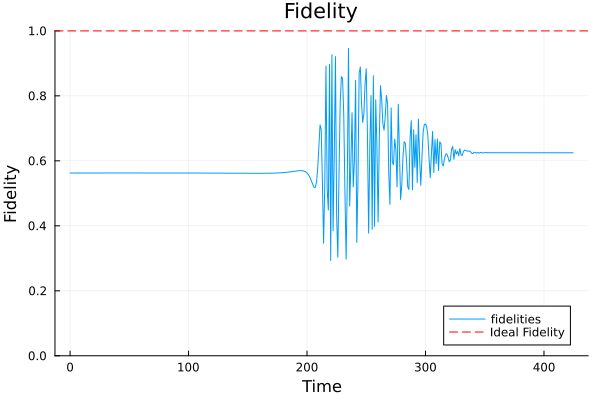

In [21]:
a = [r,r,r]
b = [g,g,g]
ψ_ideal = α*reduce(kron,a)+ β*reduce(kron,b)

fidelities = []
time = []
for (t,ρ) in zip(solution.t,solution.u)
    fidelity = ψ_ideal' * ρ * ψ_ideal
    push!(fidelities,fidelity)
    push!(time,t)
end

plot(time,real(fidelities),label="fidelities",xaxis="Time",yaxis="Fidelity",ylim=(0,1),title="Fidelity")
hline!([1], color=:red, linestyle=:dash, label="Ideal Fidelity")

## RAP for different Detuning rates

In [10]:
struct Parameters
    Ω1::Float64
    Ω2::Float64     
    γ_Decay::Float64     
    γ_dephase::Float64
    V1_nn::Float64 
    V2_nn::Float64
    δ1::Float64   
 end

In [17]:
# Parameters
function (p::Parameters)(t)
    global Δ1_0 = Δ1_0
    global Δ2_0 = Δ2_0
    
    tf = -2*(Δ1_0+p.V1_nn)/p.δ1
    return (Δ1_0+p.δ1*t, Δ2_0+p.δ1*t, p.Ω1, p.Ω2, p.γ_Decay, p.γ_dephase, p.V1_nn, p.V2_nn)
end


#Solving the master equation
function solve_master_eqn(p)
    tspan = (0.0,-2*(Δ1_0+p(0)[end-1])/p.δ1)
    eqn = ODEProblem(master_eqn, ρ_0, tspan, p)
    sol = solve(eqn, Rodas3(autodiff=false),saveat=0.01, progress=true)
    return sol
end


#Obtaining the fidelilty of |RRR> state w.r.t detuning rate
function fid_detuning(δ)
    # global Δ1_0 = Δ1_0
    # global Δ2_0 = Δ2_0

    fidelity = Array{Float64}(undef, length(δ))
    ψ_ideal = α*kron(r,r,r) + β*kron(g,g,g)

    Threads.@threads for i in 1:length(δ)
        d = δ[i]
        p = Parameters(20,20,0,0,-2000,-2000,d)
        sol = solve_master_eqn(p)

        f = tr(ψ_ideal' * sol[end] * ψ_ideal)
        fidelity[i] = real(f) 
    end
    return fidelity
end

fid_detuning (generic function with 1 method)

In [18]:
Δ1_0 = 3000
Δ2_0 = 3000
δ = -1 .*collect(range(start=1000.0,stop=10,step=-10))

Fidelity = fid_detuning(δ)

100-element Vector{Float64}:
 0.07357485722522149
 0.07805623891346988
 0.07860320238719545
 0.0767759840625538
 0.07582565705460262
 0.07708491731481752
 0.07995714492593042
 0.0831931204045074
 0.0860923478535217
 0.08848289984843205
 ⋮
 0.9402010899107371
 0.9608701532826788
 0.9772932359748737
 0.9889107793849804
 0.9957807047081159
 0.9987396667239242
 0.9996219067944623
 0.9999440740094772
 1.0005697740210362

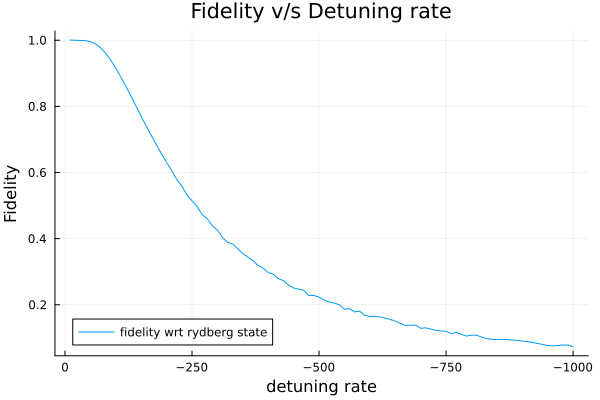

In [19]:
plot(δ,Fidelity,xflip=true, label="fidelity wrt rydberg state", legend=:bottomleft,xaxis="detuning rate",yaxis="Fidelity",title="Fidelity v/s Detuning rate")

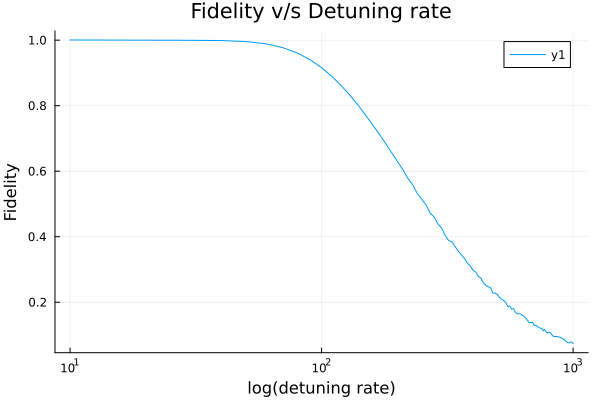

In [26]:
d = -1 .*δ
plot(d,Fidelity,xscale=:log10,xaxis="log(detuning rate)",yaxis="Fidelity",title="Fidelity v/s Detuning rate")